In [3]:
import time
import matplotlib.pyplot as plt
import pandas as pd
# import seaborn as sns # Still optional
from pynvml import *

# --- Configuration ---
COLLECTION_DURATION_SECONDS = 100  # How long to collect data
SAMPLE_INTERVAL_SECONDS = 0.0001     # How often to collect data
GPU_INDEX = 0                     # GPU index to monitor

def get_gpu_metrics(gpu_index=0):
    """
    Fetches GPU utilization, memory utilization, and power usage for the specified GPU.
    Returns (gpu_utilization, memory_utilization, power_watts) or (None, None, None) on error.
    """
    try:
        handle = nvmlDeviceGetHandleByIndex(gpu_index)

        # GPU Utilization
        utilization = nvmlDeviceGetUtilizationRates(handle)
        gpu_util = utilization.gpu

        # Memory Info
        mem_info = nvmlDeviceGetMemoryInfo(handle)
        mem_util = (mem_info.used / mem_info.total) * 100 if mem_info.total > 0 else 0

        # Power Usage
        # nvmlDeviceGetPowerUsage returns power in milliwatts
        power_milliwatts = nvmlDeviceGetPowerUsage(handle)
        power_watts = power_milliwatts / 1000.0  # Convert to Watts

        return gpu_util, mem_util, power_watts
    except NVMLError as error:
        print(f"Error getting GPU metrics for GPU {gpu_index}: {error}")
        return None, None, None
    except Exception as e: # Catch other potential errors during API calls
        print(f"An unexpected error occurred fetching metrics for GPU {gpu_index}: {e}")
        return None, None, None

def main():
    gpu_util_data = []
    mem_util_data = []
    power_draw_data = []
    time_points = [] # For the x-axis of line plots

    print(f"Starting GPU metric collection for {COLLECTION_DURATION_SECONDS} seconds...")
    print(f"Monitoring GPU {GPU_INDEX}. Data points collected every {SAMPLE_INTERVAL_SECONDS} sec.")

    try:
        nvmlInit()
    except NVMLError as e:
        print(f"Failed to initialize NVML: {e}. Ensure NVIDIA drivers are installed.")
        return

    start_time = time.time()
    collection_count = 0
    try:
        while True:
            current_collection_time = time.time() - start_time
            if current_collection_time >= COLLECTION_DURATION_SECONDS:
                break

            gpu_util, mem_util, power_watts = get_gpu_metrics(GPU_INDEX)

            if gpu_util is not None and mem_util is not None:
                gpu_util_data.append(gpu_util)
                mem_util_data.append(mem_util)
                power_draw_data.append(power_watts)
                time_points.append(current_collection_time)
                collection_count += 1
                #print(f"Collected ({collection_count}): Time: {current_collection_time:.1f}s, GPU Util: {gpu_util:.1f}%, Mem Util: {mem_util:.1f}%")
            else:
                print("Failed to retrieve metrics for a sample.")

            # Precise sleep to maintain sample interval
            sleep_duration = SAMPLE_INTERVAL_SECONDS - ( (time.time() - start_time) % SAMPLE_INTERVAL_SECONDS )
            if sleep_duration > 0 : # Ensure sleep_duration is not negative
                 time.sleep(sleep_duration)


    except KeyboardInterrupt:
        print("\nData collection interrupted by user.")
    finally:
        try:
            nvmlShutdown()
            print("NVML shut down.")
        except NVMLError as e:
            print(f"Error shutting down NVML: {e}")

    print(f"\nFinished GPU metric collection. Collected {collection_count} data points.")

    if not gpu_util_data or not mem_util_data or not power_draw_data or not time_points:
        print("No data collected to plot.")
        return

    # Create a Pandas DataFrame (optional but good practice)
    df = pd.DataFrame({
        'Time': time_points,
        'GPU_Utilization': gpu_util_data,
        'Memory_Utilization': mem_util_data,
        'Power_Watts': power_draw_data
    })
    return df



if __name__ == "__main__":
    
    df=main()

Starting GPU metric collection for 100 seconds...
Monitoring GPU 0. Data points collected every 0.0001 sec.

Data collection interrupted by user.
NVML shut down.

Finished GPU metric collection. Collected 780693 data points.


In [4]:
print(df)

                Time  GPU_Utilization  Memory_Utilization  Power_Watts
0       2.384186e-07                5            9.167702       21.257
1       5.325818e-02                5            9.167702       21.257
2       5.335498e-02                5            9.167702       21.257
3       5.345416e-02                5            9.167702       21.257
4       5.355525e-02                5            9.167702       21.257
...              ...              ...                 ...          ...
780688  7.974645e+01                1            8.894946       20.530
780689  7.974655e+01                1            8.894946       20.530
780690  7.974665e+01                1            8.894946       20.530
780691  7.974675e+01                1            8.894946       20.530
780692  7.974685e+01                1            8.894946       20.530

[780693 rows x 4 columns]


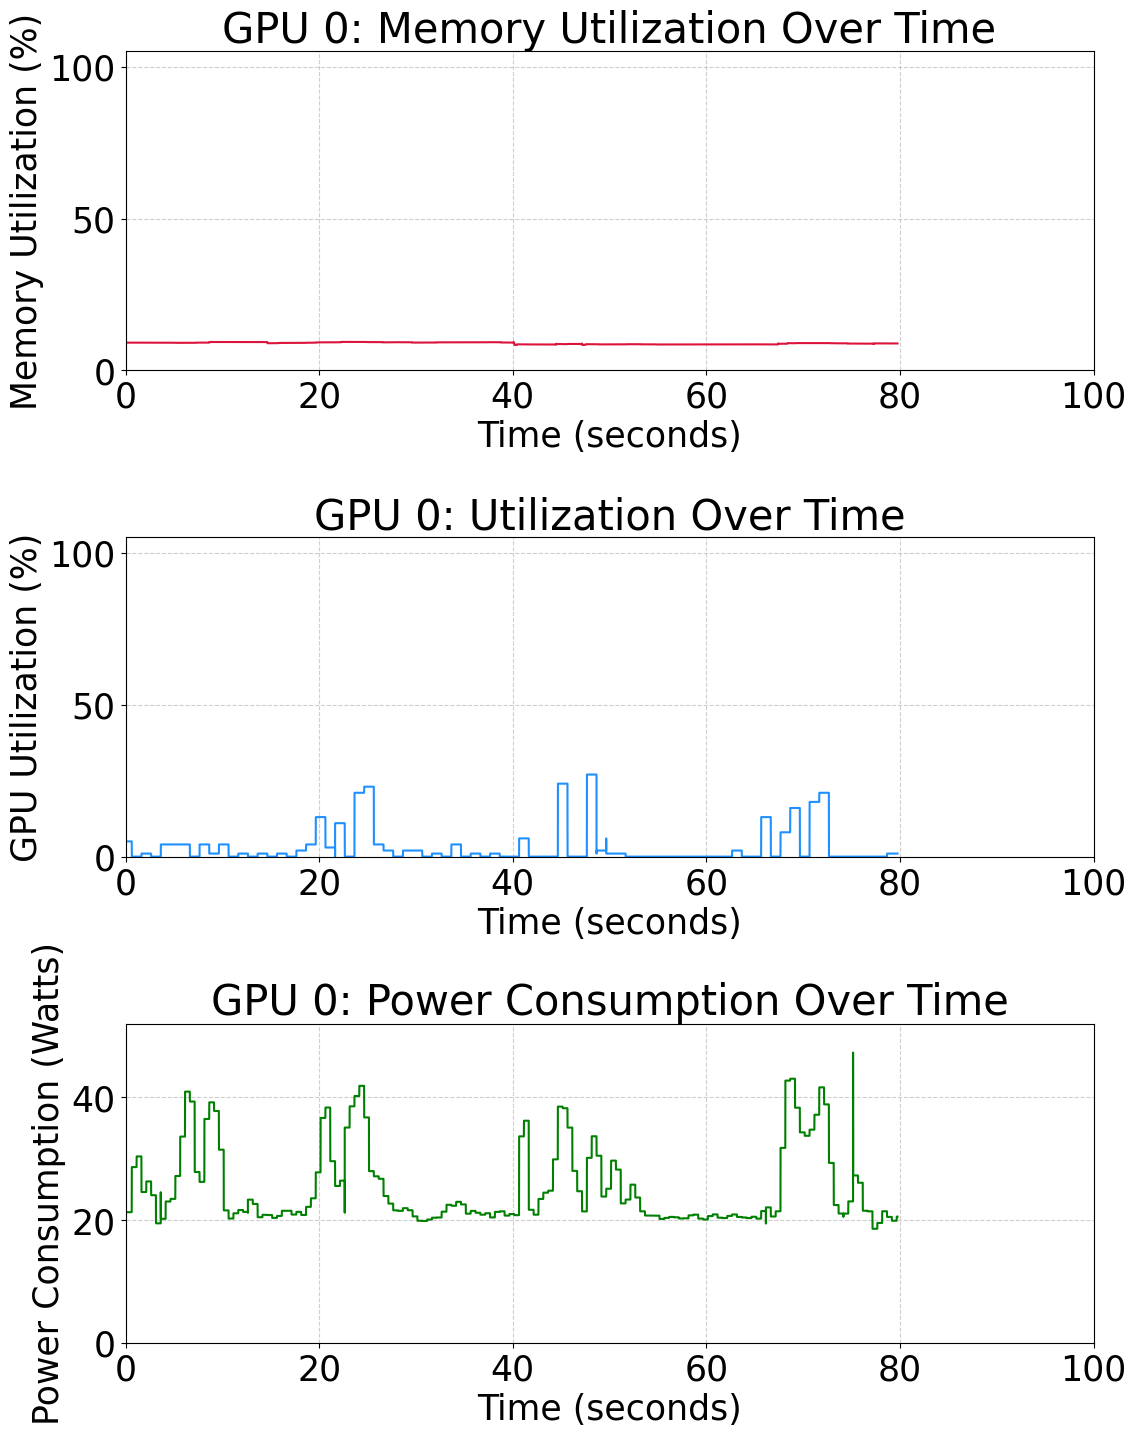

In [5]:
fig, axs = plt.subplots(3, 1, figsize=(12, 15), sharex=False) # 3 rows, 1 column

# Subplot 1: Scatter plot of GPU Utilization vs. Memory Utilization
'''scatter = axs[0].scatter(df['GPU_Utilization'], df['Memory_Utilization'],
                         c=df['Time'], cmap='viridis', alpha=0.7, edgecolors='w', linewidth=0.5)
axs[0].set_title(f'NVIDIA GPU {GPU_INDEX}: Utilization vs. Memory Utilization')
axs[0].set_xlabel('GPU Utilization (%)')
axs[0].set_ylabel('Memory Utilization (%)')
axs[0].grid(True, linestyle='--', alpha=0.6)
axs[0].set_xlim(0, 80)
'''
#fig.colorbar(scatter, ax=axs[0], label='Time (seconds from start)')
label_size=25
# Subplot 2: Line plot of GPU Utilization vs. Time
axs[1].plot(df['Time'], df['GPU_Utilization'], marker='none', linestyle='-', color='dodgerblue', markersize=4)
axs[1].set_title(f'GPU {GPU_INDEX}: Utilization Over Time',fontsize=30)
axs[1].set_xlabel('Time (seconds)',fontsize=label_size)
axs[1].set_ylabel('GPU Utilization (%)',fontsize=label_size)
axs[1].grid(True, linestyle='--', alpha=0.6)
axs[1].set_ylim(0, 105) # Give a little space above 100%
axs[1].set_xlim(left=0, right=max(df['Time']) if not df['Time'].empty else COLLECTION_DURATION_SECONDS)
axs[1].set_xlim(0, 100)
axs[1].tick_params(axis='x', labelsize=label_size)
axs[1].tick_params(axis='y', labelsize=label_size)
# Subplot 3: Line plot of Memory Utilization vs. Time
axs[0].plot(df['Time'], df['Memory_Utilization'], marker='none', linestyle='-', color='crimson', markersize=4)
axs[0].set_title(f'GPU {GPU_INDEX}: Memory Utilization Over Time',fontsize=30)
axs[0].set_xlabel('Time (seconds)',fontsize=label_size)
axs[0].set_ylabel('Memory Utilization (%)',fontsize=label_size)
axs[0].grid(True, linestyle='--', alpha=0.6)
axs[0].set_ylim(0, 105)
axs[0].set_xlim(left=0, right=max(df['Time']) if not df['Time'].empty else COLLECTION_DURATION_SECONDS)
axs[0].set_xlim(0, 100)
axs[0].tick_params(axis='x', labelsize=label_size)
axs[0].tick_params(axis='y', labelsize=label_size)
# Subplot 4: Line plot of GPU Power Consumption vs. Time
axs[2].plot(df['Time'], df['Power_Watts'], marker='none', linestyle='-', color='green', markersize=4)
axs[2].set_title(f'GPU {GPU_INDEX}: Power Consumption Over Time',fontsize=30)
axs[2].set_xlabel('Time (seconds)',fontsize=label_size)
axs[2].set_ylabel('Power Consumption (Watts)',fontsize=label_size)
axs[2].grid(True, linestyle='--', alpha=0.6)
# Adjust Y limit for power based on typical GPU power, e.g., 0 to 400W or based on data
min_power = 0
max_power = max(df['Power_Watts']) * 1.1 if not df['Power_Watts'].empty else 100 # Add 10% buffer
axs[2].set_ylim(min_power, max_power if max_power > 0 else 100) # Ensure max_power is sensible
axs[2].set_xlim(left=0, right=max(df['Time']) if not df['Time'].empty else COLLECTION_DURATION_SECONDS)
axs[2].set_xlim(0, 100)
axs[2].tick_params(axis='x', labelsize=label_size)
axs[2].tick_params(axis='y', labelsize=label_size)

plt.tight_layout(pad=3.0) # Adjust layout to prevent overlapping titles/labels
plt.show()
